In [1]:
import pandas as pd
import sys
sys.path.insert(0, "../../")
from utils.ploting_figures import MakePlots
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_opt=pd.read_csv("../../metrics/RandomForest_Grid_42_grid_metrics.csv")
df_orig=pd.read_csv("../../metrics/RandomForest_Grid_42_metrics.csv")
df_indep_excl=pd.read_csv("../../metrics/RandomForest_indep_excl_data.csv")

In [3]:
rename_dict = {
    "acc": "Accuracy",
    "recall": "Recall",
    "precision": "Precision",
    "f1": "F1-score",
    "mcc": "MCC",
    "roc_auc": "ROC-AUC",
    "model": "Algorithm",
    "dataset": "Stage",
    "sampling": "Sample"
}

In [4]:
display(df_opt.head())
display(df_orig.head())
display(df_indep_excl.head())

,dataset,model,sampling,acc,recall,precision,f1,mcc,roc_auc,conf_matrix
0,Train_opt,Random_Forest,Original,0.728571,0.728571,0.727432,0.721082,0.538333,0.900543,"{0: {0: 470, 1: 134, 2: 38}, 1: {0: 59, 1: 196..."
1,Validation_opt,Random_Forest,Original,0.414449,0.414449,0.377455,0.389325,-0.043531,0.452838,"{0: {0: 87, 1: 57, 2: 26}, 1: {0: 44, 1: 18, 2..."
2,Train_opt,Random_Forest,Under,0.842105,0.842105,0.842820,0.841268,0.764174,0.975084,"{0: {0: 131, 1: 20, 2: 8}, 1: {0: 13, 1: 123, ..."
3,Validation_opt,Random_Forest,Under,0.394958,0.394958,0.385495,0.382692,0.098050,0.543809,"{0: {0: 17, 1: 14, 2: 6}, 1: {0: 12, 1: 8, 2: ..."
4,Train_opt,Random_Forest,Over,0.794714,0.794714,0.797862,0.789294,0.698384,0.941693,"{0: {0: 388, 1: 79, 2: 1}, 1: {0: 90, 1: 363, ..."


,dataset,model,sampling,acc,recall,precision,f1,mcc,roc_auc,conf_matrix
0,Train_orig,Random_Forest,Original,0.728571,0.728571,0.726262,0.722608,0.540224,0.902442,"{0: {0: 461, 1: 129, 2: 33}, 1: {0: 62, 1: 200..."
1,Validation_orig,Random_Forest,Original,0.384030,0.384030,0.348324,0.361785,-0.087190,0.444260,"{0: {0: 84, 1: 59, 2: 22}, 1: {0: 47, 1: 13, 2..."
2,Train_orig,Random_Forest,Under,0.842105,0.842105,0.843772,0.842437,0.763598,0.975064,"{0: {0: 127, 1: 15, 2: 9}, 1: {0: 19, 1: 136, ..."
3,Validation_orig,Random_Forest,Under,0.394958,0.394958,0.393934,0.389921,0.096745,0.533617,"{0: {0: 17, 1: 13, 2: 6}, 1: {0: 13, 1: 10, 2:..."
4,Train_orig,Random_Forest,Over,0.818685,0.818685,0.817161,0.817156,0.728551,0.962128,"{0: {0: 433, 1: 109, 2: 16}, 1: {0: 78, 1: 387..."


,dataset,model,sampling,acc,recall,precision,f1,mcc,roc_auc,conf_matrix
0,Test_independent,Random_Forest,Original,0.723951,0.723951,0.729861,0.722902,0.417999,0.815537,"{0: {0: 398, 1: 98, 2: 6}, 1: {0: 69, 1: 124, ..."
1,Test_independent,Random_Forest,Undersampling,0.331529,0.331529,0.539694,0.389867,0.026470,0.487558,"{0: {0: 165, 1: 77, 2: 0}, 1: {0: 148, 1: 63, ..."
2,Test_independent,Random_Forest,Oversampling,0.625169,0.625169,0.724991,0.661735,0.344465,0.772843,"{0: {0: 322, 1: 62, 2: 0}, 1: {0: 99, 1: 123, ..."
3,Test_excluded,Random_Forest,Original,0.589286,0.589286,0.624900,0.501333,0.152257,0.710329,"{0: {0: 328, 1: 166, 2: 62}, 1: {0: 21, 1: 31,..."
4,Test_excluded,Random_Forest,Undersampling,0.488636,0.488636,0.575487,0.503015,0.224098,0.660379,"{0: {0: 195, 1: 76, 2: 6}, 1: {0: 49, 1: 53, 2..."


In [5]:
df= pd.concat([df_opt, df_orig, df_indep_excl], axis=0)

In [6]:
conf_matrix = df.filter(items=["dataset", "sampling", "conf_matrix"])
conf_matrix

,dataset,sampling,conf_matrix
0,Train_opt,Original,"{0: {0: 470, 1: 134, 2: 38}, 1: {0: 59, 1: 196..."
1,Validation_opt,Original,"{0: {0: 87, 1: 57, 2: 26}, 1: {0: 44, 1: 18, 2..."
2,Train_opt,Under,"{0: {0: 131, 1: 20, 2: 8}, 1: {0: 13, 1: 123, ..."
3,Validation_opt,Under,"{0: {0: 17, 1: 14, 2: 6}, 1: {0: 12, 1: 8, 2: ..."
4,Train_opt,Over,"{0: {0: 388, 1: 79, 2: 1}, 1: {0: 90, 1: 363, ..."
5,Validation_opt,Over,"{0: {0: 63, 1: 54, 2: 3}, 1: {0: 49, 1: 56, 2:..."
0,Train_orig,Original,"{0: {0: 461, 1: 129, 2: 33}, 1: {0: 62, 1: 200..."
1,Validation_orig,Original,"{0: {0: 84, 1: 59, 2: 22}, 1: {0: 47, 1: 13, 2..."
2,Train_orig,Under,"{0: {0: 127, 1: 15, 2: 9}, 1: {0: 19, 1: 136, ..."
3,Validation_orig,Under,"{0: {0: 17, 1: 13, 2: 6}, 1: {0: 13, 1: 10, 2:..."


In [7]:
df.drop(columns=["conf_matrix"], inplace=True)

In [8]:
df.rename(columns=rename_dict, inplace=True)
df

,Stage,Algorithm,Sample,Accuracy,Recall,Precision,F1-score,MCC,ROC-AUC
0,Train_opt,Random_Forest,Original,0.728571,0.728571,0.727432,0.721082,0.538333,0.900543
1,Validation_opt,Random_Forest,Original,0.414449,0.414449,0.377455,0.389325,-0.043531,0.452838
2,Train_opt,Random_Forest,Under,0.842105,0.842105,0.842820,0.841268,0.764174,0.975084
3,Validation_opt,Random_Forest,Under,0.394958,0.394958,0.385495,0.382692,0.098050,0.543809
4,Train_opt,Random_Forest,Over,0.794714,0.794714,0.797862,0.789294,0.698384,0.941693
5,Validation_opt,Random_Forest,Over,0.570025,0.570025,0.552304,0.554019,0.361987,0.718790
0,Train_orig,Random_Forest,Original,0.728571,0.728571,0.726262,0.722608,0.540224,0.902442
1,Validation_orig,Random_Forest,Original,0.384030,0.384030,0.348324,0.361785,-0.087190,0.444260
2,Train_orig,Random_Forest,Under,0.842105,0.842105,0.843772,0.842437,0.763598,0.975064
3,Validation_orig,Random_Forest,Under,0.394958,0.394958,0.393934,0.389921,0.096745,0.533617


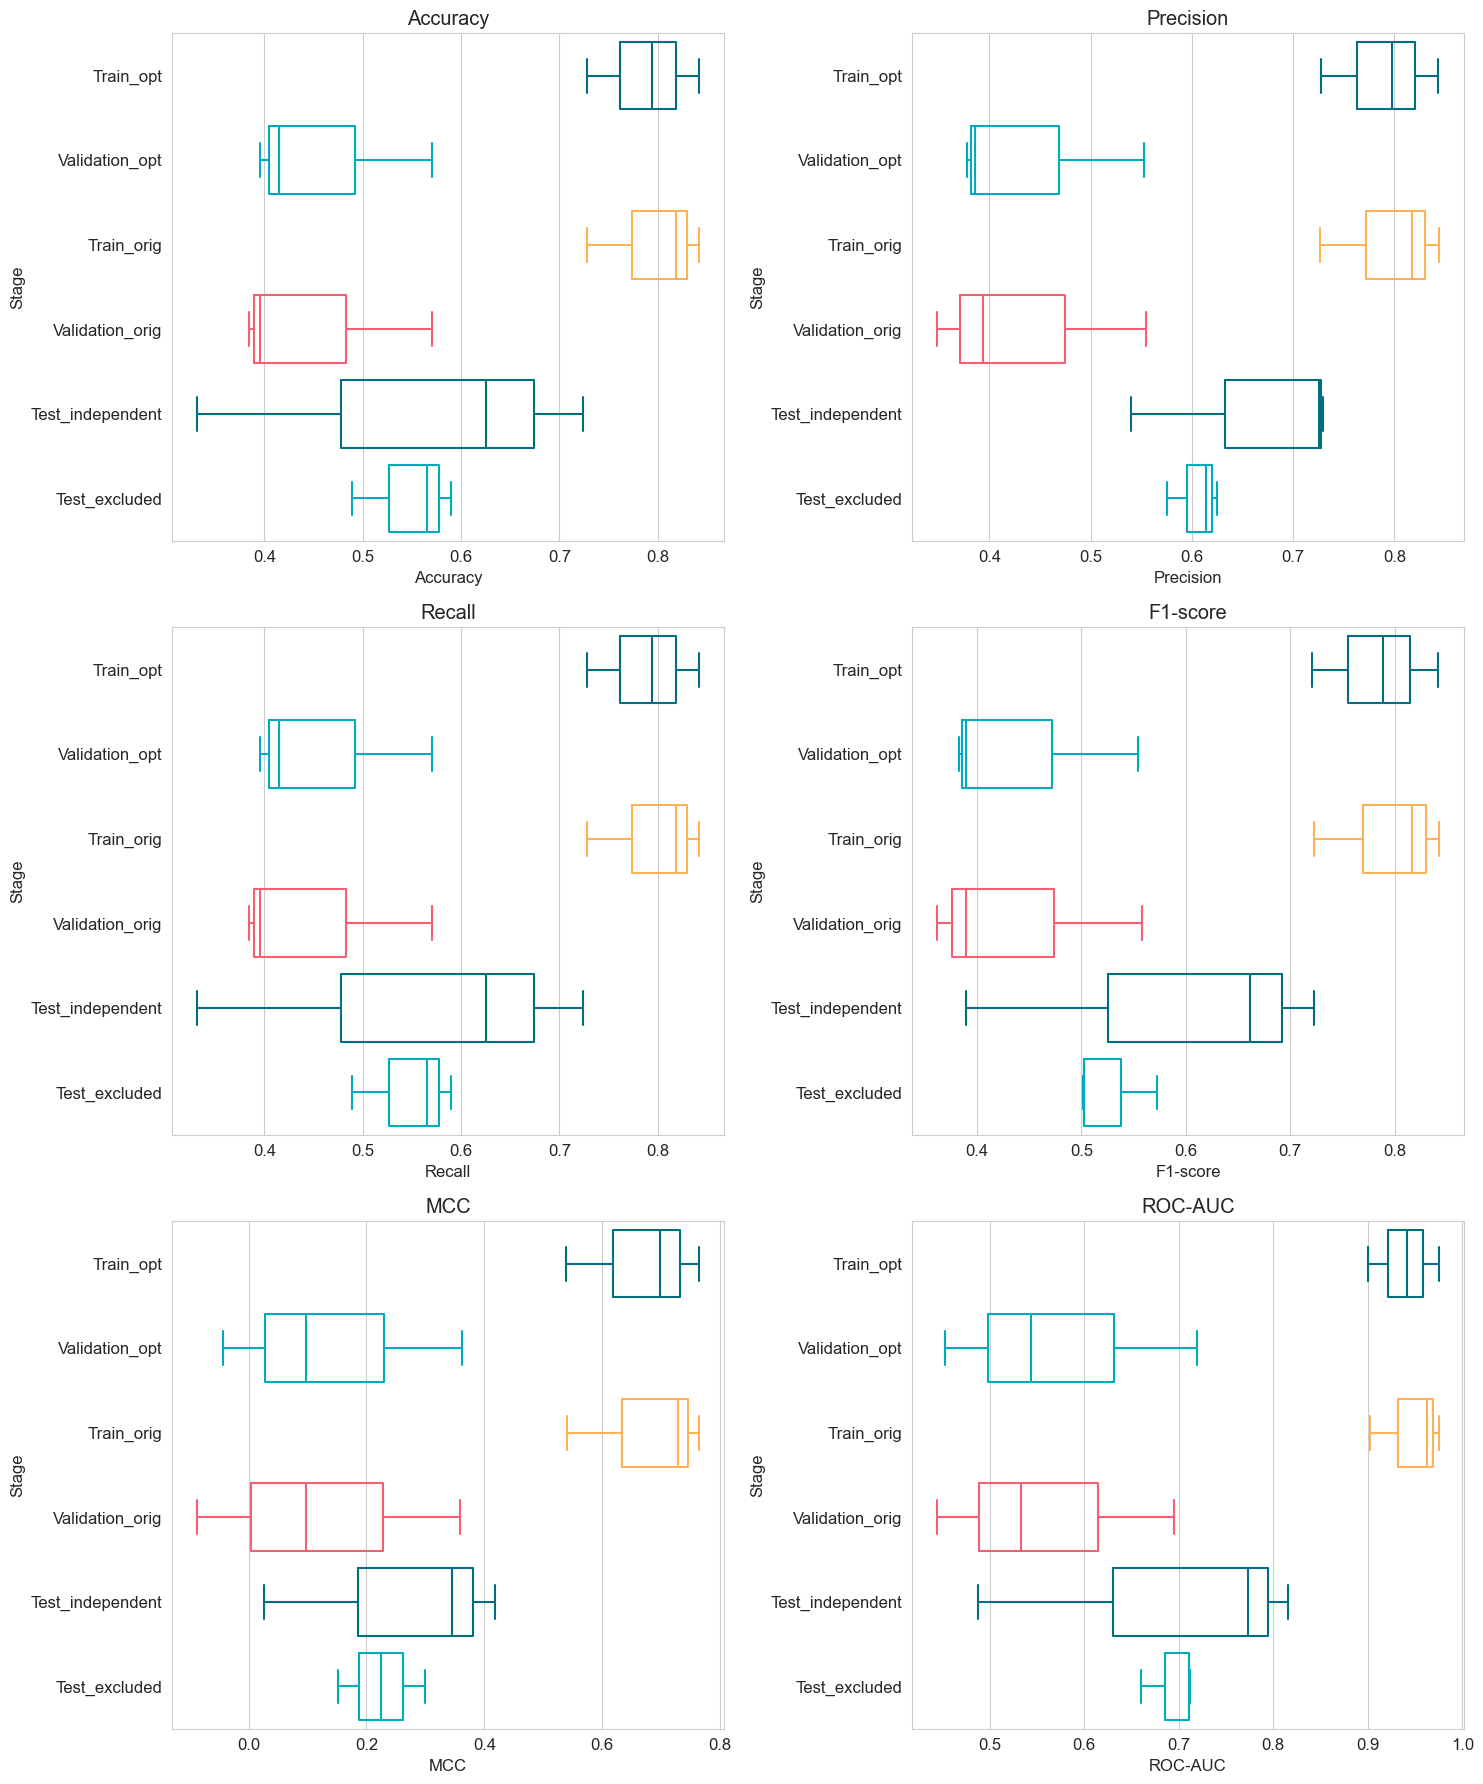

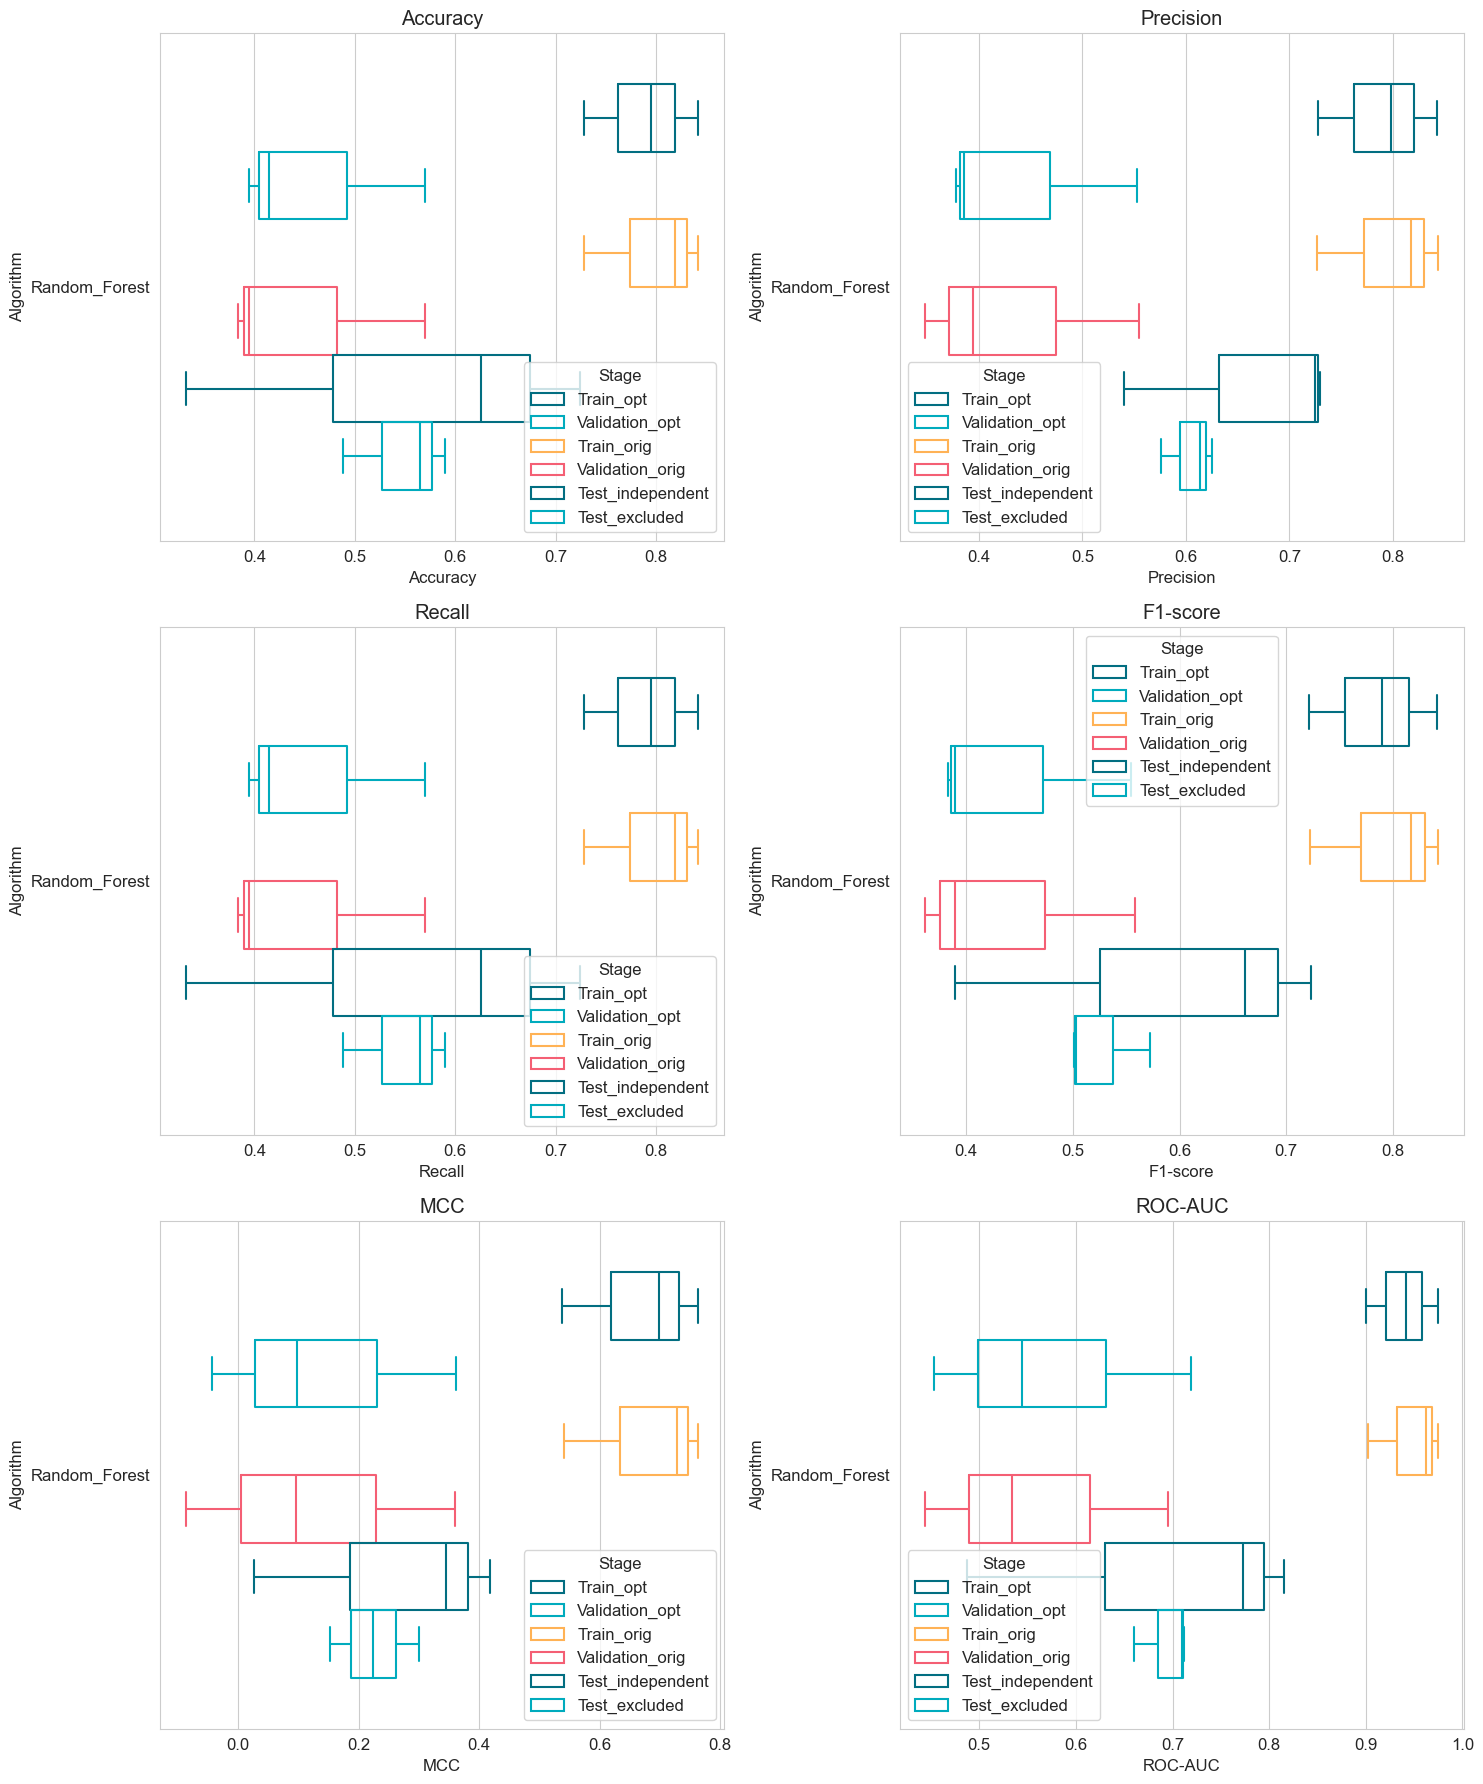

In [9]:
make_plots = MakePlots(dataset=df, path_export="../../img/numerical_rep", hue="Stage")
make_plots.plot_by_stage()
make_plots.plot_by_algorithm()